## Principal component analysis PCA

In [72]:
import pandas as pd #Pandas handles tabular data
pd.set_option('display.float_format', lambda x: '%.3f' % x) # turn off scientific notation and too much decimal blah
import matplotlib.pyplot as plt # standard plotting library
import numpy as np #Numpy for linear algebra & co
import seaborn as sns # For pretty dataviz
sns.set_style("darkgrid") # Define style for dataviz

### Load the data

In [73]:
# load dataset into Pandas DataFrame
data = pd.read_csv('data/bcn_noise_class_ml_dataset.csv')

### Brief exploration

In the following, we will do some of the standard inspections one should do with every new dataset to get a feeling for its properties.

In [74]:
# Check data types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11711 entries, 0 to 11710
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                11711 non-null  str    
 1   noise_day              11711 non-null  int64  
 2   noise_evening          11711 non-null  int64  
 3   noise_night            11711 non-null  int64  
 4   road_category          11711 non-null  int64  
 5   dist_to_trunk          11711 non-null  float64
 6   dist_to_primary        11711 non-null  float64
 7   dist_to_secondary      11711 non-null  float64
 8   dist_to_tertiary       11711 non-null  float64
 9   dist_to_residential    11711 non-null  float64
 10  dist_to_living_street  11711 non-null  float64
 11  signals                11711 non-null  float64
 12  transport              11711 non-null  float64
 13  pois                   11711 non-null  float64
 14  width                  11711 non-null  float64
 15  betweenness  

In [75]:
# Print the first 5 rows
data.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,21638868_30343649_0,2,2,1,4,1462.932,2131.093,492.905,0.000,0.000,...,0.054,0.199,36.206,0.002,0.000,0.000,0.828,0.000,0.000,0.000
1,21638865_30343650_0,1,1,0,6,1420.228,2300.048,675.721,192.975,0.000,...,0.000,0.427,15.136,0.000,0.000,0.000,0.822,0.000,0.000,0.000
2,13859746868_13859746870_0,3,2,2,5,232.688,502.125,1111.342,188.971,0.000,...,0.000,0.261,43.791,0.001,0.000,0.000,0.808,6.628,0.000,0.000
3,21638917_190981834_0,4,4,3,3,588.465,1609.386,0.000,58.492,162.715,...,0.054,0.000,50.000,0.000,0.000,0.000,0.869,0.000,0.000,0.000
4,21638891_190971702_0,3,3,3,4,1432.029,1409.121,149.242,0.000,151.351,...,0.054,0.052,50.000,0.000,0.000,0.000,0.850,0.000,0.000,0.000


In [76]:
# Descriptive statistics
data.describe()


,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
count,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,...,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000,11711.000
mean,2.709,2.528,2.053,4.635,1552.841,793.593,359.906,139.207,14.942,158.154,...,0.014,0.035,28.717,0.005,0.000,0.000,0.823,8.498,3.717,0.908
std,0.779,0.755,0.769,0.992,880.581,810.043,399.205,161.974,45.725,277.277,...,0.018,0.070,14.475,0.009,0.000,0.000,0.057,17.299,17.083,6.141
min,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.467,0.000,0.000,0.000
25%,2.000,2.000,2.000,4.000,841.861,231.754,65.434,0.000,0.000,0.000,...,0.000,0.000,16.369,0.000,0.000,0.000,0.820,0.000,0.000,0.000
50%,3.000,3.000,2.000,5.000,1513.238,556.537,243.751,98.566,0.000,81.676,...,0.007,0.005,27.272,0.001,0.000,0.000,0.836,0.750,0.000,0.000
75%,3.000,3.000,3.000,5.000,2270.331,1095.385,518.926,213.472,0.000,186.033,...,0.021,0.041,41.366,0.005,0.000,0.000,0.850,9.284,0.000,0.000
max,4.000,4.000,3.000,6.000,3795.637,4681.710,2577.192,1060.917,758.292,2415.828,...,0.054,0.427,50.000,0.090,0.000,0.000,0.884,100.000,100.000,100.000


In [77]:
import pandas as pd

# Assume your DataFrame is called df and the noise column is 'noise_day'
# Set the desired sample size (e.g., 1000)
sample_size = 50

# Calculate the proportion of each noise value in the original data
proportions = data['noise_day'].value_counts(normalize=True).sort_index()

# Calculate how many samples to take for each noise value
samples_per_value = (proportions * sample_size).round().astype(int)

# Subsample for each noise value
subsampled = pd.concat([
    data[data['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

# Shuffle the result
subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
0   0.020
1   0.040
2   0.300
3   0.520
4   0.120
Name: proportion, dtype: float64


### Preprocessing

Since in PCA exercises the features used can be of different scale (eg. meter & kilometer) or dispolay a very different variance, it is common practice in ML workflow to normalize features. By doing so, we prevent features with high variance or scale ranges to dominate.

We here apply a standard scaler, where we substract for every feature its mean, and thyen divide by its standard deviation.

$$StandardScale() = {\frac {X-\mu }{\sigma }}$$

In [78]:
from sklearn.preprocessing import StandardScaler

In [79]:
data_num = subsampled.drop(columns=['road_id', 'noise_day','noise_evening', 'noise_night'])

In [80]:
# Let's standard-scale our data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_num)

In [81]:
# What are mean and Sd now?
pd.DataFrame(data_scaled, columns=data_num.columns).describe()

,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
count,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000
mean,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000
std,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010,1.010
min,-2.764,-1.526,-0.918,-1.039,-1.084,-0.518,-0.598,-0.548,-0.868,-0.439,-1.443,-0.581,-2.988,-1.925,-6.280,-0.670,-0.279,-0.143
25%,0.219,-0.835,-0.703,-0.819,-0.736,-0.518,-0.581,-0.548,-0.868,-0.439,-0.975,-0.515,-0.558,-0.729,-0.057,-0.670,-0.279,-0.143
50%,0.219,-0.098,-0.354,-0.316,0.038,-0.518,-0.307,-0.548,-0.311,-0.439,-0.154,-0.456,0.092,0.004,0.196,-0.552,-0.279,-0.143
75%,0.219,0.753,0.467,0.605,0.327,-0.230,-0.006,0.088,0.534,-0.089,0.718,0.095,0.504,0.523,0.422,0.277,-0.279,-0.143
max,1.213,2.063,4.124,3.721,3.843,3.064,5.490,3.062,2.169,3.881,1.806,4.313,1.755,3.650,0.839,3.914,4.473,7.000


### Executing PCA

In [82]:
# Instantiate a PCA object
from sklearn.decomposition import PCA # PCA from  sklearn, the python ML standard library
model = PCA() # Number of components needs to be defined. We just for illustration take about half of the numbers of features

In [83]:
# Fit the model
model.fit(data_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [84]:
# Fit and transform the data
data_reduced = model.transform(data_scaled)
print(data_reduced)

[[-1.16902321e+00 -1.71568170e+00  3.39162073e-01 -3.61262356e-01
   1.03064323e+00 -3.05397515e-01 -6.29808733e-02  8.49297749e-01
  -1.48825434e+00  2.98102524e-01 -5.07194950e-02 -6.89228875e-01
  -7.66028729e-01  3.93190381e-01 -5.62259567e-01  5.70364547e-01
   2.99794792e-01  3.35059092e-01]
 [ 8.00458952e-01 -6.46421874e-03  1.35613715e+00  8.50777746e-01
  -1.21710982e+00 -1.95453994e-01  1.82682086e-02  4.46479684e-02
  -3.74126020e-03  2.77444528e-01  4.26271996e-01  1.08871900e-01
   6.28567848e-01  7.91882366e-01  8.85968448e-01 -2.04521623e-01
  -1.10830755e-01 -6.04193474e-01]
 [-9.88245630e-01 -2.12967674e+00  1.03706062e-01  9.89993437e-01
   3.69740878e-01  1.51208166e+00 -6.52661906e-02 -3.15124984e-01
   2.29117363e-01  5.63044953e-01  1.38656091e-01 -3.69876313e-01
   1.77966590e-02 -6.86134635e-01  3.19605145e-01  2.73789509e-01
  -1.55900531e-01 -1.11000234e-01]
 [ 4.46806359e+00 -1.82835606e+00 -1.57233859e-01  9.37553495e-01
  -2.82648080e-01 -5.88258171e-01  4.

### Inspecting Results

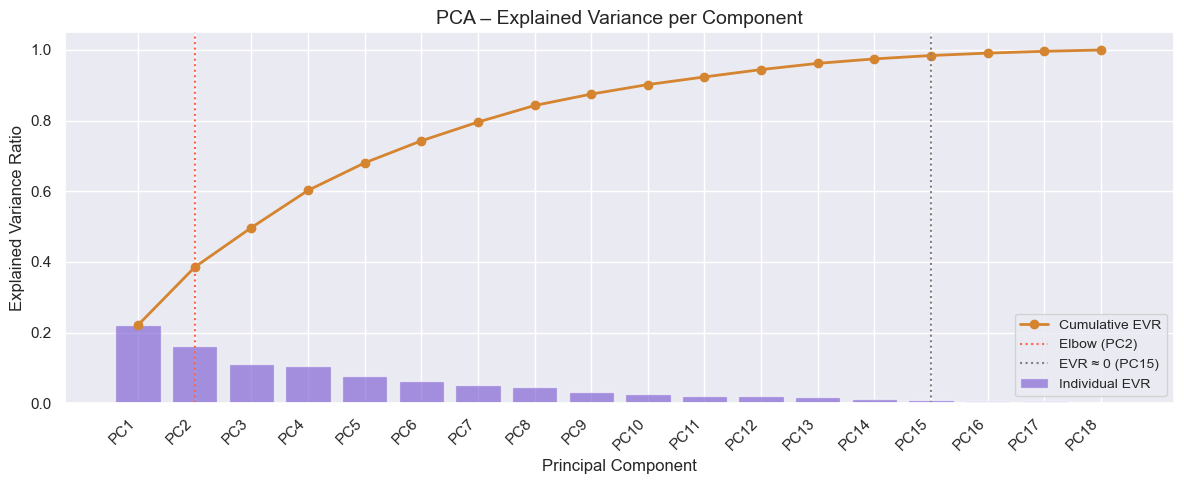

Elbow at PC2 — cumulative EVR: 38.54%
EVR ≈ 0 at PC15 — cumulative EVR: 98.44%


In [85]:
n_components = len(model.explained_variance_ratio_)
pc_labels = [f'PC{i+1}' for i in range(n_components)]

evr = model.explained_variance_ratio_
cumsum_evr = np.cumsum(evr)

# Find elbow: largest drop in EVR between consecutive components
diffs = np.diff(evr)
elbow_idx = np.argmin(diffs) + 1  # +1 because diff reduces length by 1

# Find where EVR becomes negligible (< 1% of total variance)
near_zero_idx = np.argmax(evr < 0.01)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(pc_labels, evr, alpha=0.6, label='Individual EVR', color='#7251ce')
ax.plot(pc_labels, cumsum_evr, marker='o', color='#d58430', linewidth=2, label='Cumulative EVR')
ax.axvline(x=elbow_idx, color='tomato', linestyle=':', linewidth=1.5, label=f'Elbow (PC{elbow_idx+1})')
ax.axvline(x=near_zero_idx, color='gray', linestyle=':', linewidth=1.5, label=f'EVR ≈ 0 (PC{near_zero_idx+1})')

ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance Ratio', fontsize=12)
ax.set_title('PCA – Explained Variance per Component', fontsize=14)
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Elbow at PC{elbow_idx+1} — cumulative EVR: {cumsum_evr[elbow_idx]:.2%}")
print(f"EVR ≈ 0 at PC{near_zero_idx+1} — cumulative EVR: {cumsum_evr[near_zero_idx]:.2%}")


### Note: The plot above shows that variance is spread more evenly across components (cumulative evr is steeper than evr)

In [86]:
print(model.explained_variance_ratio_)

[0.22180539 0.16363056 0.11193056 0.10532436 0.07787515 0.06235999
 0.05302966 0.04700071 0.03218915 0.02696846 0.02166709 0.02078124
 0.01762101 0.0126478  0.00958768 0.00672758 0.00520014 0.00365345]


PLOTTING ALL THE PCS

In [87]:
def myplot(score,coeff,labels=None):
    plot_df = pd.DataFrame(score[:, 0:2], columns=['PC1', 'PC2'])
    plot_df['noise_day'] = subsampled['noise_day'].values

    # Scale factors for visual clarity
    scalex = 1.0 / (plot_df['PC1'].max() - plot_df['PC1'].min())
    scaley = 1.0 / (plot_df['PC2'].max() - plot_df['PC2'].min())

    # Plot the scatter using seaborn
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='noise_day', palette='deep', s=60, edgecolor='k', alpha=0.8)
    
    # Plot arrows representing variable loadings
    n = coeff.shape[0]
    arrow_scale = 3  # adjust this to make arrows longer
    for i in range(n):
        plt.arrow(
            0, 0,
            arrow_scale * coeff[i, 0],
            arrow_scale * coeff[i, 1],
            color='red',
            alpha=0.6,
            head_width=0.05,
            head_length=0.07,
            linewidth=1.5
        )
        label = data_num.columns[i] if labels is None else labels[i]
        plt.text(
            arrow_scale * coeff[i, 0] * 1.1,
            arrow_scale * coeff[i, 1] * 1.1,
            label,
            color='black',
            ha='center',
            va='center'
        )

    # Aesthetic adjustments
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Biplot")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



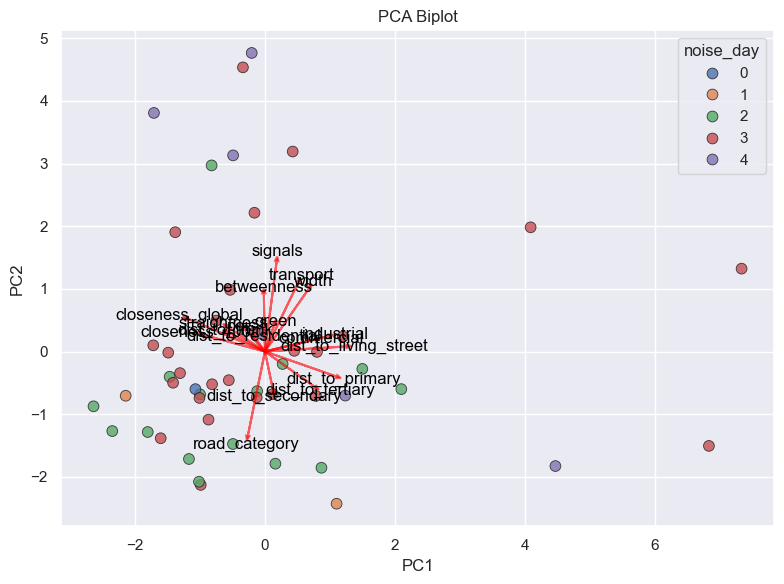

In [88]:
#Call the function. Use only the 2 PCs.
myplot(data_reduced[:,0:2],np.transpose(model.components_[0:2, :]),labels=data_num.columns)
plt.show()


The important features are the ones that influence more the components and thus, have a large absolute value/score on the component.

In [89]:
pcscores = pd.DataFrame(data_reduced)
loadings = pd.DataFrame(model.components_, columns=data_num.columns)
loadings.index = ['PC'+str(i+1) for i in range(len(pcscores.columns))]

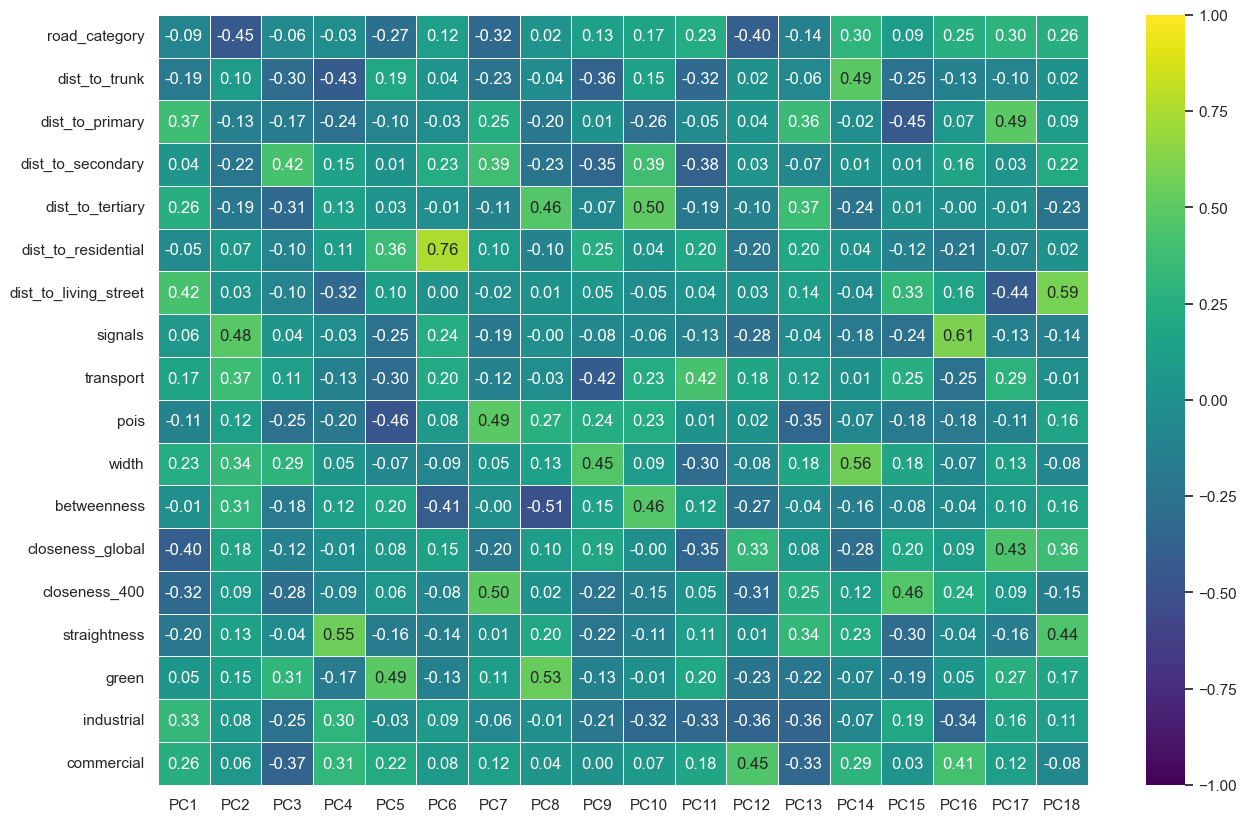

In [90]:
ax = sns.heatmap(loadings.transpose(), center=0, linewidths=0.5,
                 cmap="viridis", vmin=-1, vmax=1, annot=True, fmt=".2f")

# TSNE

In [91]:
# Separate features and labels
features = data_num  # Assuming 'species' is the label column
labels = data['noise_day']  # Replace with your actual label column name

In [92]:
from sklearn.manifold import TSNE

# Fit and transform the features using t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features)


In [93]:
# Create a new DataFrame with the t-SNE results
tsne_df = pd.DataFrame(tsne_results, columns=['TSNE-1', 'TSNE-2'])
tsne_df['noise_day'] = labels



In [94]:
tsne_df

,TSNE-1,TSNE-2,noise_day
0,-0.652,-0.188,2
1,-0.466,3.671,1
2,-0.113,3.415,3
3,-2.361,4.464,4
4,-1.247,4.828,3
5,-1.490,-0.214,4
6,-0.129,3.862,3
7,-1.817,3.540,2
8,-0.373,0.491,1
9,-1.867,3.744,2


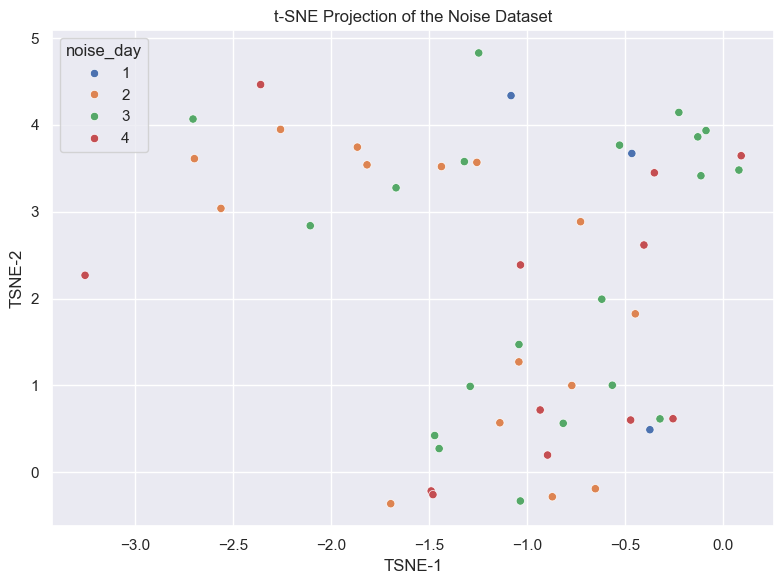

In [95]:
# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df,
    x='TSNE-1', y='TSNE-2',
    hue='noise_day',
    palette='deep'
)
plt.title('t-SNE Projection of the Noise Dataset')
plt.tight_layout()
plt.show()

# Minisom

In [96]:
from sklearn.preprocessing import MinMaxScaler

# Normalise the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(data_num)


In [97]:
from minisom import MiniSom

# Define and train the SOM
som_size = (5, 5)  # You can adjust the grid size
som = MiniSom(x=som_size[0], y=som_size[1], input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train(X_scaled, num_iteration=1000, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.36999381339360177


In [98]:
y = labels
label_to_int = {label: idx for idx, label in enumerate(np.unique(y))}
y_numeric = [label_to_int[label] for label in y]

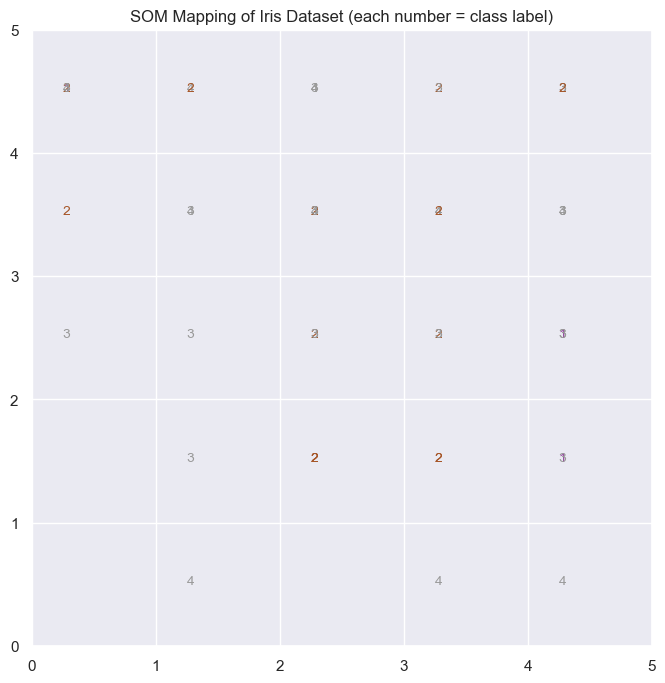

In [99]:
# Create a plot of the SOM with mapped labels
plt.figure(figsize=(8, 8))
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    plt.text(w[0] + 0.25, w[1] + 0.5, str(y[i]),
             color=plt.cm.Set1(y_numeric[i] / 3),
             fontdict={'size': 10})

plt.xlim([0, som_size[0]])
plt.ylim([0, som_size[1]])
plt.title("SOM Mapping of Iris Dataset (each number = class label)")
plt.grid(True)
plt.show()